In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv('olist_dataset/orders_clean.csv')
products = pd.read_csv('olist_dataset/products_clean.csv')
customers = pd.read_csv('olist_dataset/customers_clean.csv')
order_items = pd.read_csv('olist_dataset/order_items_clean.csv')
payments = pd.read_csv('olist_dataset/payments_clean.csv')
reviews = pd.read_csv('olist_dataset/reviews_clean.csv')

In [3]:
df = orders.merge(customers, on = 'customer_id', how = 'left')\
            .merge(order_items, on = 'order_id', how = 'left')\
            .merge(products, on = 'product_id' , how = 'left')\
            .merge(payments, on = 'order_id', how = 'left')\
            .merge(reviews, on = 'order_id', how = 'left')
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (115695, 36)


In [4]:
df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
order_item_id                      int64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm

In [5]:
date_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'shipping_limit_date',
    'review_creation_date', 'review_answer_timestamp'
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

In [6]:
df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
customer_unique_id                          str
customer_zip_code_prefix                  int64
customer_city                               str
customer_state                              str
order_item_id                             int64
product_id                                  str
seller_id                                   str
shipping_limit_date              datetime64[us]
price                                   float64
freight_value                           float64
product_name_lenght                     float64
product_description_lenght              float64
product_photos_qty                      

### check missing value

In [7]:
print('Null count:\n', df.isnull().sum())

Null count:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_name_lenght              1638
product_description_lenght       1638
product_photos_qty               1638
product_weight_g                 1638
product_length_cm                1638
product_height_cm                1638
product_width_cm                 1638
product_category_name            1638

In [8]:
df_clean = df.dropna(subset = ['product_category_name','payment_type','review_score']).copy()

In [9]:
print("New Shape:", df_clean.shape)
print("\nRemaining Null Count:\n",df_clean.isnull().sum())

New Shape: (113205, 36)

Remaining Null Count:
 order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name            0
payment_sequential               0
payment

In [12]:
import scipy.stats as stats

## Chi-Square Test

In [13]:
contingency_table = pd.crosstab(df_clean['payment_type'], df_clean['review_score'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Statistc: {chi2: .4f}")
print(f"p-value: {p}")
if p < 0.05:
    print("Conclusion: Payment type and Review score are significantly related.")
else:
    print("Conclusion: No significant relationship found.")

Chi-Square Statistc:  37.2198
p-value: 0.00020578684338357154
Conclusion: Payment type and Review score are significantly related.


1. **Payment Type & Customer Satisfaction:**
   - **Finding:** There is a statistically significant relationship between the payment method chosen by the customer and their final review score(p = 0.0002).
   - **Business Takeway:** Customer satisfaction varies depending on how they pay. Customers using specific payment optins(e.g.,credit card installments vs. boleto/voucher) may have difference expectations, cash-flow friction, or refund experiences that directly impact their ratings.

In [14]:
contingency_table2 = pd.crosstab(df_clean['payment_type'], df_clean['customer_state'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table2)
print(f"Chi-Square Statistc: {chi2: .4f}")
print(f"p-value: {p}")
if p < 0.05:
    print("Conclusion: Payment type and Customer State are significantly related.")
else:
    print("Conclusion: No significant relationship found.")

Chi-Square Statistc:  592.3740
p-value: 4.246196996770577e-80
Conclusion: Payment type and Customer State are significantly related.


2. **Regional Payment Preferences:**
   - **Finding:** Payment preference is strongly dependent on the customer's geographic location  ($p = 4.25 \times 10^{-80}$).
   - **Business Takeway:** Regional payment habits vary significantly across Brazil. Certain states rely heavily on cash-based payments (like Boleto), while others prefer credit card installments. Marketing campaigns and checkout strategies should be tailored to match regional financial preferences.

## ANOVA Test

In [28]:
# case 1 ANOVA test of payment value according to Payment type
payment_groups = [group['payment_value'].values for name, group in df_clean.groupby('payment_type')]
f_stat_pay, p_val_pay = stats.f_oneway(*payment_groups)

print("--- Payment Type vs Payment Value ---")
print(f"F-statistic: {f_stat_pay:.4f}")
print(f"p-value: {p_val_pay}")

if p_val_pay < 0.05:
    print("Conclusion: Significant diffirence in payment value across payment types.")
else:
    print("Conclusion: No significant difference found.")


--- Payment Type vs Payment Value ---
F-statistic: 359.4216
p-value: 2.4126945884855186e-232
Conclusion: Significant diffirence in payment value across payment types.


3. **Payment Value across Payment Types**
   - **Finding:** $F = 359.42$, $p = 2.41 \times 10^{-232}$. Total payment value differs significantly across different payment methods.
   - **Business Takeaway:** Credit card installments are typically used for higher-value transactions, whereas single-payment options (like Boleto or Vouchers) are used for lower-value purchases. Promoting installment options can help drive higher Average Order Value (AOV).

In [27]:
# case 2 ANOVA test of price acccording to top 10 product category

top10_cats = df_clean['product_category_name'].value_counts().head(10).index
cat_groups = [df_clean[df_clean['product_category_name'] == cat]['price'].values for cat in top10_cats]
f_stat_cat, p_val_cat = stats.f_oneway(*cat_groups)
print("--- Top 10 Product Categories vs Price ---")
print(f"F-statistic: {f_stat_cat:.4f}")
print(f"p-value: {p_val_cat}")

if p_val_cat<0.05:
    print("Conclusion: Product prices vary significantly across top categories.")
else:
    print("Conclusion: No significant price difference across categories.")

--- Top 10 Product Categories vs Price ---
F-statistic: 316.7775
p-value: 0.0
Conclusion: Product prices vary significantly across top categories.


4. **Product Price across Top Categories**
   - **Finding:** $F = 316.78$, $p < 0.0001$ (reported as $0.0$). Product prices vary significantly across top product categories.
   - **Business Takeaway:** Different product categories operate under completely different price points and margins (e.g., watches/gifts vs. housewares). Pricing, discounting, and promotional strategies must be customized per category rather than applied uniformly.

## T-test

In [29]:
df_clean['is_delayed'] = df_clean['order_delivered_customer_date'] > df_clean['order_estimated_delivery_date']

delayed_scores = df_clean[df_clean['is_delayed'] == True]['review_score']
ontime_scores = df_clean[df_clean['is_delayed'] == False]['review_score']

t_stat, p_val = stats.ttest_ind(delayed_scores,ontime_scores)

print("--- Two-Sample T-Test: Delivery Delay vs Review Score ---")
print(f"Delayed Orders Count: {len(delayed_scores)} (Mean Rating: {delayed_scores.mean():2f})")
print(f"Ontime Orders Count: {len(ontime_scores)} (Mean Rating: {ontime_scores.mean():2f})")
print(f"T-statistic: {t_stat:.4f}")
print(f"p-value: {p_val}")

if p_val < 0.05:
    print("Conclusion: Review scores are significantly lower for delayed orders.")
else:
    print("Conclusion: No significant difference in review scores.")

--- Two-Sample T-Test: Delivery Delay vs Review Score ---
Delayed Orders Count: 8714 (Mean Rating: 2.549002)
Ontime Orders Count: 104491 (Mean Rating: 4.210372)
T-statistic: -117.2324
p-value: 0.0
Conclusion: Review scores are significantly lower for delayed orders.


5. **Impact of Delivery Delays on Customer Satisfaction (Two-Sample T-Test)**
   - **Finding:** $t = -117.23$, $p < 0.0001$ (reported as $0.0$). Delayed orders have a significantly lower mean review score ($2.55$) compared to on-time orders ($4.21$).
   - **Business Takeaway:** Late delivery is the single biggest driver of poor customer reviews. Improving logistics efficiency, partnering with reliable shipping carriers, and setting realistic estimated delivery dates are critical to boosting overall customer retention and platform ratings.

## Correlation Analysis

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
num_cols = ['price','freight_value','product_weight_g','product_photos_qty','review_score']

corr_matrix = df_clean[num_cols].corr()
print('--- Correlation Matrix ---')
corr_matrix

--- Correlation Matrix ---


,price,freight_value,product_weight_g,product_photos_qty,review_score
price,1.000000,0.412906,0.341482,0.053096,0.003273
freight_value,0.412906,1.000000,0.611884,0.022427,-0.033631
product_weight_g,0.341482,0.611884,1.000000,0.022141,-0.026889
product_photos_qty,0.053096,0.022427,0.022141,1.000000,0.021176
review_score,0.003273,-0.033631,-0.026889,0.021176,1.000000


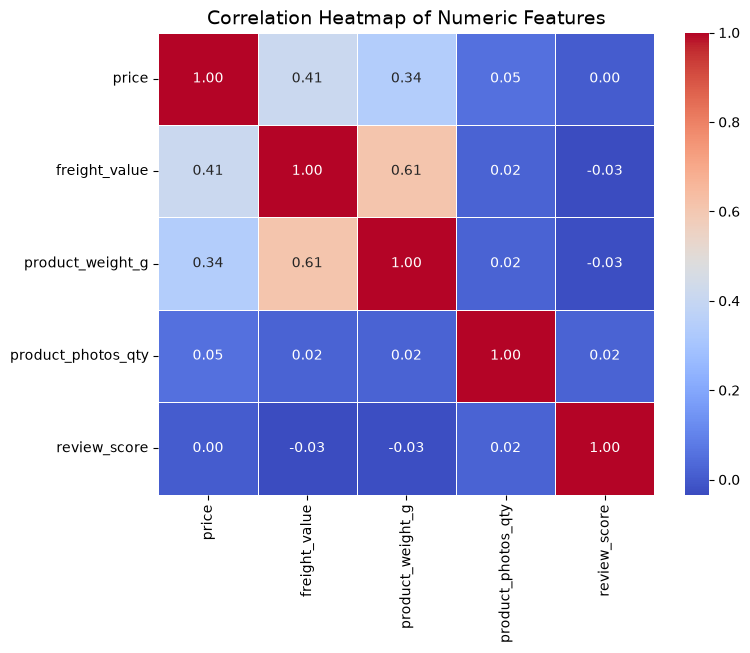

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features',fontsize = 14)
plt.show()

6. **Correlation Analysis among Numerical Features**
   - **Strong Correlation (`product_weight_g` vs `freight_value`):**
     - **Finding:** Moderate to strong positive correlation ($r = 0.61$).
     - **Business Takeaway:** Shipping cost (`freight_value`) is primarily determined by product weight rather than item price. Heavy products significantly drive up logistics expenses.

   - **Moderate Correlation (`price` vs `freight_value` & `product_weight_g`):**
     - **Finding:** Moderate positive correlation with price ($r = 0.41$ for freight, $r = 0.34$ for weight).
     - **Business Takeaway:** Higher-priced items tend to be slightly heavier and cost more to ship, though price alone is not the main driver of shipping costs.

   - **No/Negligible Correlation (`review_score` with all features):**
     - **Finding:** Correlation of `review_score` with price ($0.00$), freight ($-0.03$), weight ($-0.03$), and photos ($0.02$) is close to zero.
     - **Business Takeaway:** Product price, shipping cost, or the number of photos do NOT directly dictate customer satisfaction. A customer is equally likely to give a high rating to a cheap item as an expensive one. Satisfaction is driven by external operational factors like delivery timeliness and product quality rather than price tag.